# 03c - BERTopic: iteraciones con embeddings contextuales

Esta notebook retoma la parte final del Práctico 3: usar BERTopic para pasar de clusters exploratorios a tópicos más interpretables. La idea es probar tres configuraciones y comparar sus resultados con métricas, términos representativos y ejemplos.

A diferencia de NMF y LDA, BERTopic sí usa embeddings contextuales como insumo principal. Para que la notebook sea reproducible y no recalcule Sentence-BERT en cada ejecución, se reutiliza el cache generado en `data/processed/`.

## Preparación y cache de embeddings

Para BERTopic se usan embeddings de Sentence-BERT. A diferencia de TF-IDF, acá no se quitan stopwords antes de calcular la representación semántica: el modelo fue entrenado con oraciones completas y las palabras funcionales también ayudan a conservar estructura, negaciones y matices del texto. Quitar stopwords en esta etapa puede empobrecer el embedding.

Las stopwords se usan más adelante en el `CountVectorizer`, es decir, en la representación c-TF-IDF que BERTopic utiliza para nombrar tópicos. Ahí sí conviene filtrarlas para que los términos representativos no queden dominados por palabras de alta frecuencia. Si el archivo `.npy` de embeddings existe y la metadata coincide con el hash de textos, se carga desde disco. Si no existe o no coincide, se recalcula y se guarda.


In [1]:
from pathlib import Path
import hashlib
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import nltk
from nltk.corpus import stopwords

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from umap import UMAP

nltk.download("stopwords", quiet=True)

PROCESSED_DIR = Path("../data/processed") if Path.cwd().name == "notebooks" else Path("data/processed")
REPORTS_DIR = Path("../reports") if Path.cwd().name == "notebooks" else Path("reports")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SENTENCE_BERT_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
SENTENCE_BERT_EMBEDDINGS_PATH = PROCESSED_DIR / "sentence_bert_rawContent_sin_simbolos_con_stopwords_embeddings.npy"
SENTENCE_BERT_METADATA_PATH = PROCESSED_DIR / "sentence_bert_rawContent_sin_simbolos_con_stopwords_metadata.json"

In [2]:
df = pd.read_csv(PROCESSED_DIR / "df_final.csv")
print(df.shape)
df[["rawContent_clean", "pysentimiento"]].head()

(8882, 78)


,rawContent_clean,pysentimiento
0,Boluda ahí dice que yo debería pesar 43kg eso ...,NEG
1,"Jugador de +30 años, vendehumo, con tendencias...",NEG
2,La tabla de mi pediatra cuando tenia 6 años y ...,NEG
3,chupame un huevo como voy a pesar 48 kg midien...,NEG
4,Eso me da curiosidad en la gente obesa. Miro k...,NEU


In [3]:
stop_words = set(stopwords.words("spanish"))
custom_stopwords = set(["si", "no", "sos", "vos", "jaja", "la"])
all_stopwords = stop_words.union(custom_stopwords)

def limpiar_texto(texto):
    texto = re.sub(r"[^a-zA-Z0-9áéíóúüñÁÉÍÓÚÜÑ ]+", "", str(texto))
    texto = texto.lower()
    return texto

# Para Sentence-BERT conservamos stopwords: solo normalizamos símbolos y mayúsculas.
df["rawContent_sin_simbolos_con_stopwords"] = df["rawContent_clean"].apply(limpiar_texto)
docs = df["rawContent_sin_simbolos_con_stopwords"].fillna("").tolist()

df[["rawContent_clean", "rawContent_sin_simbolos_con_stopwords"]].head()


,rawContent_clean,rawContent_sin_simbolos_con_stopwords
0,Boluda ahí dice que yo debería pesar 43kg eso ...,boluda ahí dice que yo debería pesar 43kg eso ...
1,"Jugador de +30 años, vendehumo, con tendencias...",jugador de 30 años vendehumo con tendencias a ...
2,La tabla de mi pediatra cuando tenia 6 años y ...,la tabla de mi pediatra cuando tenia 6 años y ...
3,chupame un huevo como voy a pesar 48 kg midien...,chupame un huevo como voy a pesar 48 kg midien...
4,Eso me da curiosidad en la gente obesa. Miro k...,eso me da curiosidad en la gente obesa miro ki...


In [4]:
tweets_hash = hashlib.sha256("\n".join(docs).encode("utf-8")).hexdigest()
expected_metadata = {
    "model_name": SENTENCE_BERT_MODEL_NAME,
    "source_column": "rawContent_sin_simbolos_con_stopwords",
    "n_documents": len(docs),
    "tweets_sha256": tweets_hash,
}

use_cached_embeddings = False
if SENTENCE_BERT_EMBEDDINGS_PATH.exists() and SENTENCE_BERT_METADATA_PATH.exists():
    with open(SENTENCE_BERT_METADATA_PATH, "r", encoding="utf-8") as f:
        cached_metadata = json.load(f)
    embeddings = np.load(SENTENCE_BERT_EMBEDDINGS_PATH)
    use_cached_embeddings = (
        all(cached_metadata.get(key) == value for key, value in expected_metadata.items())
        and embeddings.shape[0] == len(docs)
    )

if use_cached_embeddings:
    print(f"Embeddings Sentence-BERT cargados desde cache: {SENTENCE_BERT_EMBEDDINGS_PATH}")
else:
    model = SentenceTransformer(SENTENCE_BERT_MODEL_NAME)
    embeddings = model.encode(docs, show_progress_bar=True).astype(np.float32)
    np.save(SENTENCE_BERT_EMBEDDINGS_PATH, embeddings)
    metadata = {**expected_metadata, "embedding_shape": list(embeddings.shape)}
    with open(SENTENCE_BERT_METADATA_PATH, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)
    print(f"Embeddings Sentence-BERT calculados y guardados en: {SENTENCE_BERT_EMBEDDINGS_PATH}")

embeddings.shape

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/278 [00:00<?, ?it/s]

Embeddings Sentence-BERT calculados y guardados en: ../data/processed/sentence_bert_rawContent_sin_simbolos_con_stopwords_embeddings.npy


(8882, 384)

## Configuraciones de BERTopic

Se prueban tres variantes:

- `base`: configuración intermedia, cercana al uso estándar.
- `granular`: busca tópicos más pequeños y específicos.
- `conservadora`: exige grupos más grandes, reduce fragmentación y suele aumentar outliers.

La comparación se guarda para no depender solo de una lectura cualitativa.

In [5]:
bertopic_vectorizer_params = {
    "ngram_range": (1, 2),
    "min_df": 1,
    "max_df": 1.0,
}
vectorizer_model = CountVectorizer(
    stop_words=list(all_stopwords),
    **bertopic_vectorizer_params,
)
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

bertopic_variants = {
    "base": {
        "umap": {"n_neighbors": 15, "n_components": 5, "min_dist": 0.0, "metric": "cosine"},
        "hdbscan": {"min_cluster_size": 20, "min_samples": 5, "metric": "euclidean"},
    },
    "granular": {
        "umap": {"n_neighbors": 10, "n_components": 5, "min_dist": 0.0, "metric": "cosine"},
        "hdbscan": {"min_cluster_size": 10, "min_samples": 3, "metric": "euclidean"},
    },
    "conservadora": {
        "umap": {"n_neighbors": 30, "n_components": 5, "min_dist": 0.05, "metric": "cosine"},
        "hdbscan": {"min_cluster_size": 50, "min_samples": 10, "metric": "euclidean"},
    },
}

bertopic_variants

{'base': {'umap': {'n_neighbors': 15,
   'n_components': 5,
   'min_dist': 0.0,
   'metric': 'cosine'},
  'hdbscan': {'min_cluster_size': 20,
   'min_samples': 5,
   'metric': 'euclidean'}},
 'granular': {'umap': {'n_neighbors': 10,
   'n_components': 5,
   'min_dist': 0.0,
   'metric': 'cosine'},
  'hdbscan': {'min_cluster_size': 10,
   'min_samples': 3,
   'metric': 'euclidean'}},
 'conservadora': {'umap': {'n_neighbors': 30,
   'n_components': 5,
   'min_dist': 0.05,
   'metric': 'cosine'},
  'hdbscan': {'min_cluster_size': 50,
   'min_samples': 10,
   'metric': 'euclidean'}}}

## Funciones de evaluación

Además de contar tópicos y outliers, se calcula diversidad de términos, NPMI aproximado, y métricas geométricas sobre embeddings para documentos no outliers. Estas métricas son orientativas: BERTopic no optimiza silhouette directamente, pero sirven para comparar variantes.

In [6]:
binary_vectorizer = CountVectorizer(stop_words=list(all_stopwords), ngram_range=(1, 2), min_df=5, binary=True)
X_binary = binary_vectorizer.fit_transform(docs)

bertopic_metrics = []
bertopic_terms = []
bertopic_assignments = []

def topic_diversity(terms_df, top_n=10):
    top_terms = terms_df[terms_df["rank"] <= top_n]["term"].tolist()
    return len(set(top_terms)) / len(top_terms) if top_terms else np.nan

def mean_npmi(terms_df, binary_matrix, vectorizer, top_n=10):
    feature_index = {term: idx for idx, term in enumerate(vectorizer.get_feature_names_out())}
    binary_csc = binary_matrix.astype(bool).astype(int).tocsc()
    n_docs = binary_matrix.shape[0]
    scores = []
    for _, group in terms_df[terms_df["rank"] <= top_n].groupby("topic"):
        terms = [term for term in group.sort_values("rank")["term"] if term in feature_index]
        for i in range(len(terms)):
            for j in range(i + 1, len(terms)):
                idx_i = feature_index[terms[i]]
                idx_j = feature_index[terms[j]]
                col_i = binary_csc[:, idx_i]
                col_j = binary_csc[:, idx_j]
                p_i = col_i.sum() / n_docs
                p_j = col_j.sum() / n_docs
                p_ij = col_i.multiply(col_j).sum() / n_docs
                if p_ij > 0 and p_i > 0 and p_j > 0:
                    pmi = np.log(p_ij / (p_i * p_j))
                    scores.append(pmi / (-np.log(p_ij)))
    return float(np.mean(scores)) if scores else np.nan

def extract_topic_terms(topic_model, variant, n_terms=12):
    rows = []
    topic_ids = sorted([topic for topic in topic_model.get_topics().keys() if topic != -1])
    for topic_id in topic_ids:
        for rank, (term, weight) in enumerate(topic_model.get_topic(topic_id)[:n_terms], start=1):
            rows.append({
                "method": "BERTopic",
                "variant": variant,
                "topic": int(topic_id),
                "rank": rank,
                "term": term,
                "weight": float(weight),
            })
    return pd.DataFrame(rows)

def probability_vector(topic_model, probabilities, n_docs):
    if probabilities is None:
        values = getattr(topic_model.hdbscan_model, "probabilities_", np.ones(n_docs))
    else:
        values = probabilities
    values = np.asarray(values)
    if values.ndim == 2:
        values = values.max(axis=1)
    return values.astype(float)

def geometric_metrics(labels, embeddings, max_sample=3000):
    labels = np.asarray(labels)
    mask = labels != -1
    unique_labels = np.unique(labels[mask])
    if mask.sum() < 10 or len(unique_labels) < 2:
        return {"silhouette_cosine": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    rng = np.random.default_rng(RANDOM_STATE)
    valid_indices = np.where(mask)[0]
    if len(valid_indices) > max_sample:
        valid_indices = rng.choice(valid_indices, size=max_sample, replace=False)
    sampled_embeddings = embeddings[valid_indices]
    sampled_labels = labels[valid_indices]
    return {
        "silhouette_cosine": float(silhouette_score(sampled_embeddings, sampled_labels, metric="cosine")),
        "davies_bouldin": float(davies_bouldin_score(sampled_embeddings, sampled_labels)),
        "calinski_harabasz": float(calinski_harabasz_score(sampled_embeddings, sampled_labels)),
    }


## Ejecución o carga desde cache

Cada variante guarda sus resultados. Si la metadata coincide con textos, embeddings y parámetros, se cargan los CSV ya generados. Si algo cambia, se vuelve a ajustar BERTopic.

In [7]:
def run_or_load_bertopic_variant(variant, params):
    prefix = f"bertopic_{variant}"
    assignments_path = PROCESSED_DIR / f"{prefix}_document_assignments.csv"
    terms_path = REPORTS_DIR / f"{prefix}_topic_terms.csv"
    metrics_path = REPORTS_DIR / f"{prefix}_metrics.json"
    metadata_path = PROCESSED_DIR / f"{prefix}_metadata.json"

    metadata = {
        "variant": variant,
        "docs_sha256": tweets_hash,
        "embedding_shape": list(embeddings.shape),
        "params": params,
        "vectorizer_params": {**bertopic_vectorizer_params, "ngram_range": list(bertopic_vectorizer_params["ngram_range"])},
    }

    if assignments_path.exists() and terms_path.exists() and metrics_path.exists() and metadata_path.exists():
        cached_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        if cached_metadata == metadata:
            assignments_df = pd.read_csv(assignments_path)
            terms_df = pd.read_csv(terms_path)
            metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
            print(f"{variant}: resultados cargados desde cache")
            return assignments_df, terms_df, metrics, None

    umap_model = UMAP(random_state=RANDOM_STATE, low_memory=True, **params["umap"])
    hdbscan_model = HDBSCAN(prediction_data=True, **params["hdbscan"])
    topic_model = BERTopic(
        embedding_model=None,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        calculate_probabilities=False,
        verbose=False,
    )
    topics, probabilities = topic_model.fit_transform(docs, embeddings)
    probability = probability_vector(topic_model, probabilities, len(docs))

    assignments_df = pd.DataFrame({
        "doc_id": df.index,
        "method": "BERTopic",
        "variant": variant,
        "topic": topics,
        "probability": probability,
        "is_outlier": np.asarray(topics) == -1,
    })
    terms_df = extract_topic_terms(topic_model, variant, n_terms=12)

    non_outlier = assignments_df[~assignments_df["is_outlier"]]
    topic_sizes = non_outlier["topic"].value_counts()
    metrics = {
        "method": "BERTopic",
        "variant": variant,
        "n_topics": int(non_outlier["topic"].nunique()),
        "outlier_rate": float(assignments_df["is_outlier"].mean()),
        "min_topic_size": int(topic_sizes.min()) if not topic_sizes.empty else 0,
        "median_topic_size": float(topic_sizes.median()) if not topic_sizes.empty else np.nan,
        "max_topic_size": int(topic_sizes.max()) if not topic_sizes.empty else 0,
        "mean_assignment_probability": float(assignments_df["probability"].mean()),
        "median_assignment_probability": float(assignments_df["probability"].median()),
        "topic_diversity": topic_diversity(terms_df, top_n=10),
        "mean_npmi": mean_npmi(terms_df, X_binary, binary_vectorizer, top_n=10),
        **geometric_metrics(assignments_df["topic"].values, embeddings),
    }

    assignments_df.to_csv(assignments_path, index=False)
    terms_df.to_csv(terms_path, index=False)
    metrics_path.write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")
    metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"{variant}: BERTopic ajustado y guardado")
    return assignments_df, terms_df, metrics, topic_model

variant_models = {}
for variant, params in bertopic_variants.items():
    assignments_df, terms_df, metrics, topic_model = run_or_load_bertopic_variant(variant, params)
    bertopic_assignments.append(assignments_df)
    bertopic_terms.append(terms_df)
    bertopic_metrics.append(metrics)
    if topic_model is not None:
        variant_models[variant] = topic_model

bertopic_metrics_df = pd.DataFrame(bertopic_metrics)
bertopic_terms_df = pd.concat(bertopic_terms, ignore_index=True)
bertopic_assignments_df = pd.concat(bertopic_assignments, ignore_index=True)
bertopic_metrics_df

base: BERTopic ajustado y guardado


granular: BERTopic ajustado y guardado


conservadora: BERTopic ajustado y guardado


,method,variant,n_topics,outlier_rate,min_topic_size,median_topic_size,max_topic_size,mean_assignment_probability,median_assignment_probability,topic_diversity,mean_npmi,silhouette_cosine,davies_bouldin,calinski_harabasz
0,BERTopic,base,66,0.426931,20,37.5,713,0.498658,0.595287,0.989394,0.506161,-0.001057,2.850544,21.592197
1,BERTopic,granular,177,0.355325,10,19.0,452,0.557254,0.755694,0.992655,0.585545,-0.031697,2.726631,9.783813
2,BERTopic,conservadora,3,0.000000,111,319.0,8452,0.966782,1.000000,0.933333,0.074855,0.065222,2.715727,34.118183


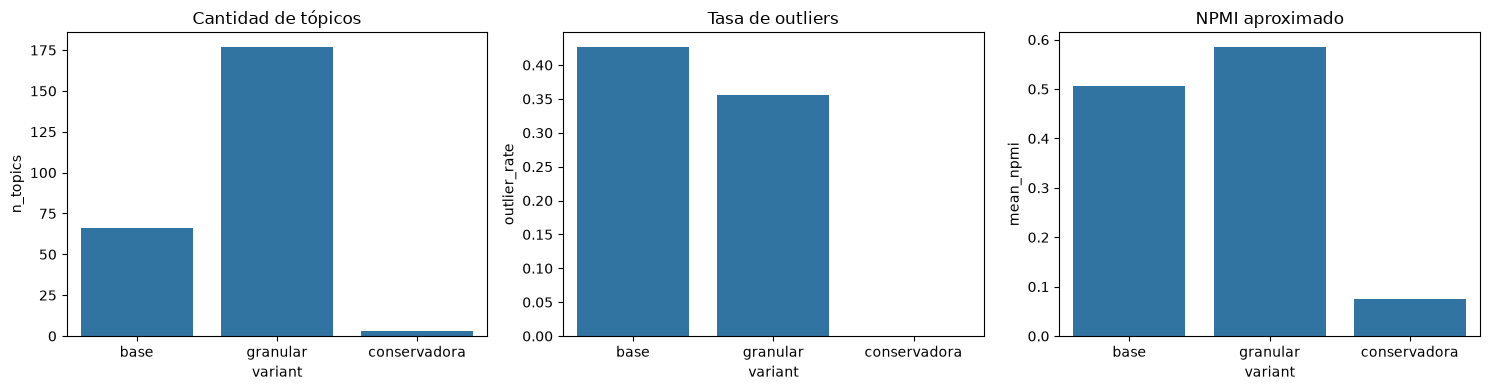

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=bertopic_metrics_df, x="variant", y="n_topics", ax=axes[0])
sns.barplot(data=bertopic_metrics_df, x="variant", y="outlier_rate", ax=axes[1])
sns.barplot(data=bertopic_metrics_df, x="variant", y="mean_npmi", ax=axes[2])
axes[0].set_title("Cantidad de tópicos")
axes[1].set_title("Tasa de outliers")
axes[2].set_title("NPMI aproximado")
plt.tight_layout()
plt.show()

In [9]:
candidate_metrics = bertopic_metrics_df.copy()

# Para portfolio no alcanza con maximizar NPMI: demasiados tópicos fragmentan la lectura.
# Se prioriza una zona interpretable y luego se ordena por coherencia/diversidad.
valid_candidates = candidate_metrics[
    (candidate_metrics["outlier_rate"] <= 0.5)
    & (candidate_metrics["n_topics"].between(10, 120))
]
if valid_candidates.empty:
    valid_candidates = candidate_metrics[candidate_metrics["outlier_rate"] <= 0.5]
if valid_candidates.empty:
    valid_candidates = candidate_metrics

selected_variant = valid_candidates.sort_values(
    ["mean_npmi", "topic_diversity", "outlier_rate"],
    ascending=[False, False, True],
).iloc[0]["variant"]

selected_terms = bertopic_terms_df[bertopic_terms_df["variant"] == selected_variant]
selected_assignments = bertopic_assignments_df[bertopic_assignments_df["variant"] == selected_variant]

print(f"Variante seleccionada para inspección: {selected_variant}")
display(bertopic_metrics_df.sort_values("mean_npmi", ascending=False))
display(selected_terms.pivot(index="topic", columns="rank", values="term").head(20))


Variante seleccionada para inspección: base


,method,variant,n_topics,outlier_rate,min_topic_size,median_topic_size,max_topic_size,mean_assignment_probability,median_assignment_probability,topic_diversity,mean_npmi,silhouette_cosine,davies_bouldin,calinski_harabasz
1,BERTopic,granular,177,0.355325,10,19.0,452,0.557254,0.755694,0.992655,0.585545,-0.031697,2.726631,9.783813
0,BERTopic,base,66,0.426931,20,37.5,713,0.498658,0.595287,0.989394,0.506161,-0.001057,2.850544,21.592197
2,BERTopic,conservadora,3,0.000000,111,319.0,8452,0.966782,1.000000,0.933333,0.074855,0.065222,2.715727,34.118183


rank,1,2,3,4,5,6,7,8,9,10
topic,,,,,,,,,,
0,siento,voy,kg,kilos,quiero,mido,siento obesa,pesaba,dios,peso
1,mujer,mujeres,chica,hombres,chicas,gay,lesbiana,seora,mujeres obesas,mujer obesa
2,diabetes,obesidad diabetes,diabetes tipo,medicamentos,diabetes obesidad,medicamento,riesgo,insulina,semaglutida,cncer
3,argentina,argentinos,argentino,colombiano,chile,mexicanos,mexicano,brasil,venezuela,pas
4,sobrepeso sobrepeso,blabla,sobrepeso,sobrepeso cgt,tenes sobrepeso,sobrepeso hace,bk,perritolovers merecen,dt arquero,pepe argento
5,gordura,gordura hinchazn,hinchazn,gordura gordura,confundas,confundas gordura,hinchazn gordura,gordura tambin,gordura hace,hablar gordura
6,robots,kuka,pelo,cha,bajara,cementerio ravioles,obeso vamos,cha cha,adorni,lechona
7,obesidad enfermedad,enfermedad,anorexia,enfermedad obesidad,fibrosis,crnica,cancer,grave,enfermedades,problemas salud
8,puta,madre,concha madre,concha,puta madre,re mil,obeso mierda,mil puta,mierda,lul


## Proyección 2D de la variante seleccionada

Para mantener la misma lógica visual de `03a`, se proyectan los embeddings a dos dimensiones y se colorean por tópico. La proyección no define los tópicos; sirve para inspeccionar separación y mezcla visual.

In [10]:
coords_path = PROCESSED_DIR / f"bertopic_{selected_variant}_umap_2d.csv"
if coords_path.exists():
    coords_df = pd.read_csv(coords_path)
else:
    reducer_2d = UMAP(n_components=2, n_neighbors=15, min_dist=0.05, metric="cosine", random_state=RANDOM_STATE, low_memory=True)
    coords = reducer_2d.fit_transform(embeddings)
    coords_df = pd.DataFrame({"doc_id": df.index, "x": coords[:, 0], "y": coords[:, 1]})
    coords_df.to_csv(coords_path, index=False)

plot_df = coords_df.merge(selected_assignments[["doc_id", "topic", "probability", "is_outlier"]], on="doc_id")
plot_df["topic_label"] = np.where(plot_df["is_outlier"], "outlier", plot_df["topic"].astype(str))
fig = px.scatter(
    plot_df,
    x="x",
    y="y",
    color="topic_label",
    hover_data=["topic", "probability"],
    title=f"BERTopic {selected_variant} - proyección UMAP 2D",
    opacity=0.75,
)
fig.show()

## Ejemplos representativos

Se revisan tweets con mayor probabilidad dentro de algunos tópicos. Esto permite contrastar si las palabras que nombran el tópico se corresponden con documentos reales.

In [11]:
top_topics = selected_assignments[~selected_assignments["is_outlier"]]["topic"].value_counts().head(5).index.tolist()
for topic_id in top_topics[:3]:
    print(f"BERTopic {selected_variant} - tópico {topic_id}")
    selected_docs = selected_assignments[selected_assignments["topic"] == topic_id].sort_values("probability", ascending=False).head(5)
    display(df.loc[selected_docs["doc_id"], ["rawContent_clean", "pysentimiento"]].assign(probability=selected_docs["probability"].values))

BERTopic base - tópico 0


,rawContent_clean,pysentimiento,probability
8875,boludo JAJSHAJA entonces yo tengo obesidad mór...,NEG,1.0
0,Boluda ahí dice que yo debería pesar 43kg eso ...,NEG,1.0
8872,por esta mierda una conocida ahora pesa 150kg ...,NEG,1.0
8,y claro con razón el médico me dice obeso com...,NEG,1.0
15,Y yo me mato haciéndole croquetitas de cualqui...,NEG,1.0


BERTopic base - tópico 1


,rawContent_clean,pysentimiento,probability
8879,"Mal, no es obesa pero es gordita.",NEU,1.0
8704,"No puede estar más boludita, encima bardea dic...",NEG,1.0
8701,"Si, pero no esa cantidad, esa chica tiene much...",NEG,1.0
8699,Está bien que desde chica inculcarle el habito...,NEU,1.0
8637,"Tras el macabro hallazgo, y poner en resguardo...",NEG,1.0


BERTopic base - tópico 2


,rawContent_clean,pysentimiento,probability
8739,En realidad es una medicación para la diabetes...,NEU,1.0
8697,| Cuidado con el medicamento de moda: el puede...,NEG,1.0
8622,"No se, acá Cristina dijo q la diabetes tipo 2...",NEG,1.0
8523,Estas en el país de los diabeticos y obesos. M...,NEG,1.0
49,"En el 2023, una nueva clase de fármacos para p...",POS,1.0


## Salidas para comparación final

Se consolidan los resultados de las tres variantes para que la página final pueda comparar métodos, tópicos, métricas y asignaciones.

In [12]:
bertopic_metrics_df.to_csv(REPORTS_DIR / "bertopic_model_metrics.csv", index=False)
bertopic_terms_df.to_csv(REPORTS_DIR / "bertopic_topic_terms.csv", index=False)
bertopic_assignments_df.to_csv(PROCESSED_DIR / "bertopic_document_assignments.csv", index=False)

print(REPORTS_DIR / "bertopic_model_metrics.csv")
print(REPORTS_DIR / "bertopic_topic_terms.csv")
print(PROCESSED_DIR / "bertopic_document_assignments.csv")

../reports/bertopic_model_metrics.csv
../reports/bertopic_topic_terms.csv
../data/processed/bertopic_document_assignments.csv


## Cierre

BERTopic permite combinar embeddings contextuales con una representación legible de tópicos. La comparación entre variantes muestra el intercambio principal: configuraciones más granulares producen más tópicos y pueden capturar temas específicos, mientras que configuraciones conservadoras reducen fragmentación pero pueden dejar más documentos como outliers o tópicos demasiado generales. Esta notebook deja una selección explícita para inspección, pero conserva las tres salidas para la visualización final.